# Image Object Recognition using MobileNetV2 Transfer Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

K.set_image_data_format('channels_last')

## 1. Data loading

In [2]:
train_path = '/kaggle/input/datasets/mdjahed0/imagenet-small-dataset-for-alexnet/training_set-20260824T150746Z-1-001/training_set'
test_path  = '/kaggle/input/datasets/mdjahed0/imagenet-small-dataset-for-alexnet/test_set-20260824T150536Z-1-001/test_set'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train.class_indices.keys())
print("Classes:", class_names)
print("Train samples:", train.samples, "| Val samples:", val.samples, "| Test samples:", test.samples)

Found 3200 images belonging to 10 classes.
Found 800 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.
Classes: ['bear', 'bird', 'crocodile', 'dogs', 'elephant', 'fungus', 'goldfish', 'jellyfish', 'leopard', 'monkey']
Train samples: 3200 | Val samples: 800 | Test samples: 1000


In [3]:
print("Batch size for input image:", train[0][0].shape)
print("Batch size for output label:", train[0][1].shape)
print("Image size for first image:", train[0][0][0].shape)
print("Output size of first label:", train[0][1][0].shape)

Batch size for input image: (32, 224, 224, 3)
Batch size for output label: (32, 10)
Image size for first image: (224, 224, 3)
Output size of first label: (10,)


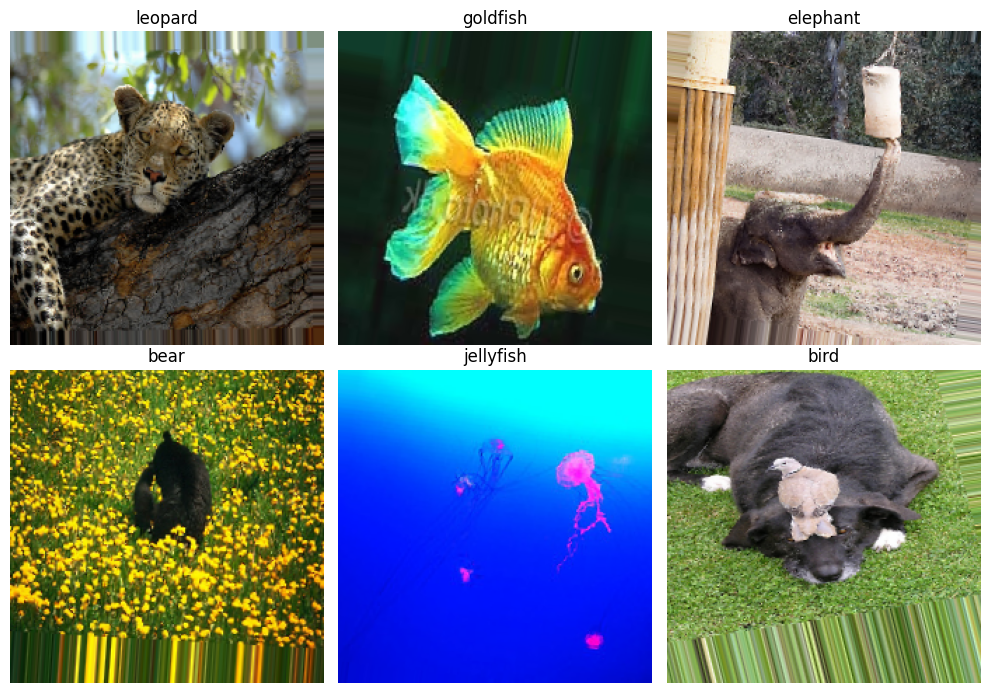

In [4]:
images = train[0][0]
labels = train[0][1]

def label_to_text(label, class_names):
    idx = int(np.argmax(label))
    return class_names[idx]

# preprocess_input shifts pixel values outside 0-1, so re-normalize just for display
def to_displayable(img):
    img = img - img.min()
    img = img / (img.max() + 1e-8)
    return img

indices = [0, 1, 2, 3, 4, 5]
fig, axs = plt.subplots(2, 3, figsize=(10, 7))
for ax, idx in zip(axs.flat, indices):
    ax.imshow(to_displayable(images[idx]))
    ax.set_title(label_to_text(labels[idx], class_names))
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. MobileNetV2 transfer learning architecture

In [5]:
def build_model(input_shape, num_classes):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = False   # freeze the pretrained base

    X = base_model.output
    X = GlobalAveragePooling2D()(X)
    X = Dense(256, activation='relu')(X)
    X = Dropout(0.5)(X)
    X = Dense(num_classes, activation='softmax', name='fc_out')(X)

    model = Model(inputs=base_model.input, outputs=X, name='MobileNetV2_transfer')
    return model

In [12]:
num_classes = len(class_names)
alex = build_model(train[0][0].shape[1:], num_classes)
alex.summary()

Model: "MobileNetV2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 3. Training

In [13]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

alex.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [14]:
history = alex.fit(train,validation_data=val,epochs=20,callbacks=[early_stop, reduce_lr])


Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 79s 698ms/step - accuracy: 0.8159 - loss: 0.6125 - val_accuracy: 0.9187 - val_loss: 0.2637 - learning_rate: 0.0010
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 56s 561ms/step - accuracy: 0.9216 - loss: 0.2673 - val_accuracy: 0.9175 - val_loss: 0.2768 - learning_rate: 0.0010
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 59s 595ms/step - accuracy: 0.9369 - loss: 0.2086 - val_accuracy: 0.8988 - val_loss: 0.3426 - learning_rate: 0.0010
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 585ms/step - accuracy: 0.9400 - loss: 0.1966 - val_accuracy: 0.9100 - val_loss: 0.2737 - learning_rate: 0.0010
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 58s 584ms/step - accuracy: 0.9541 - loss: 0.1466 - val_accuracy: 0.9300 - val_loss: 0.2415 - learning_rate: 5.0000e-04
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 553ms/step - accuracy: 0.9631 - loss: 0.1187 - val_accuracy: 0.9212 - val_loss: 0.2396 - learning_rate: 5.0000e-04
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 55s 553ms/step - accur

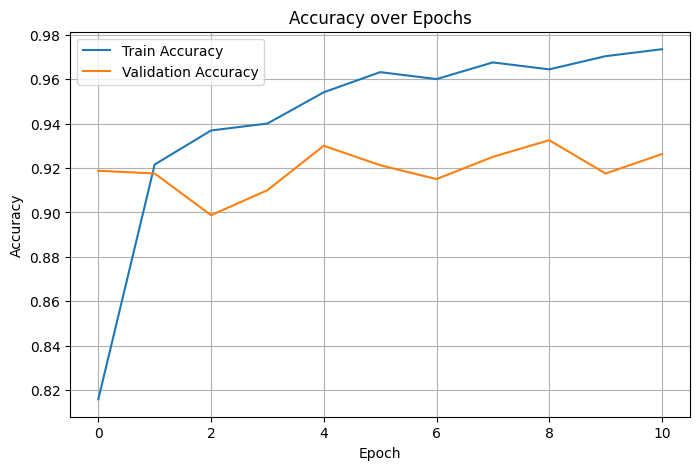

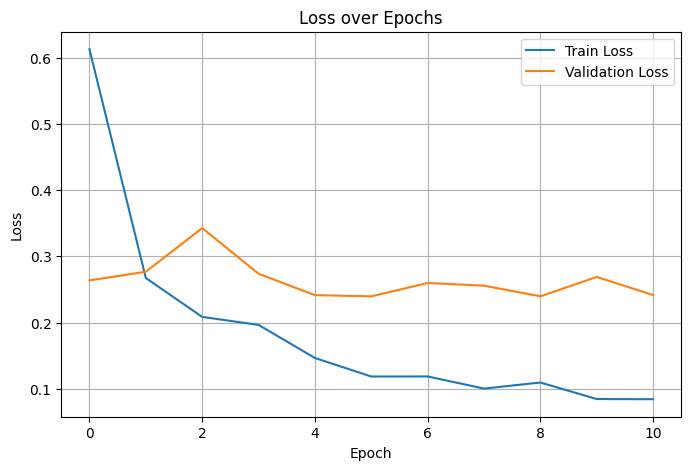

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 4. Real evaluation on the test set

In [16]:
test_loss, test_acc = alex.evaluate(test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.9553 - loss: 0.1596

2026-08-26 18:27:23.254039: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 18:27:23.391323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 648ms/step - accuracy: 0.9590 - loss: 0.1517
Test Loss: 0.1517
Test Accuracy: 0.9590


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 274ms/step
              precision    recall  f1-score   support

        bear       0.94      0.94      0.94       100
        bird       0.97      0.95      0.96       100
   crocodile       0.96      0.98      0.97       100
        dogs       0.88      0.98      0.93       100
    elephant       0.97      0.92      0.94       100
      fungus       0.94      0.97      0.96       100
    goldfish       0.99      0.99      0.99       100
   jellyfish       0.99      0.98      0.98       100
     leopard       0.99      1.00      1.00       100
      monkey       0.97      0.88      0.92       100

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



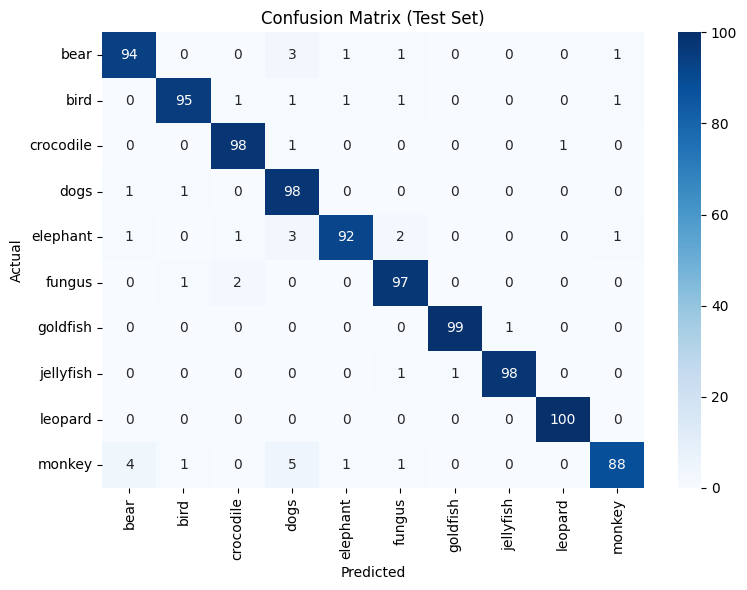

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_probs = alex.predict(test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

## 5. Prediction with the trained model

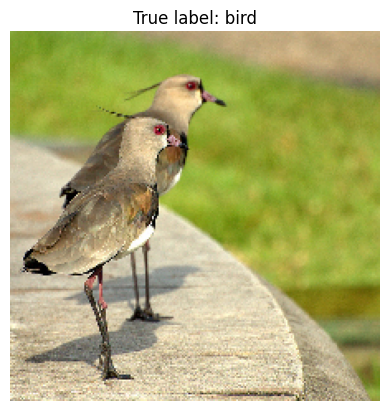

In [23]:
img_full_path = "/kaggle/input/datasets/mdjahed0/imagenet-small-dataset-for-alexnet/training_set-20260824T150746Z-1-001/training_set/bird/n01503061_14738.JPEG"

true_label = os.path.basename(os.path.dirname(img_full_path))

img = image.load_img(img_full_path, target_size=IMG_SIZE)
plt.imshow(img)
plt.axis('off')
plt.title(f"True label: {true_label}")
plt.show()

In [24]:
img_array = image.img_to_array(img) / 255.0
img_batch = np.expand_dims(img_array, axis=0)

prediction = alex.predict(img_batch)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

print(f"Predicted class: {predicted_class} (confidence: {confidence:.2%})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted class: bird (confidence: 99.98%)
